#Install and Load

In [2]:
!pip install prophet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load clean data
from google.colab import files
uploaded = files.upload()  # upload walmart_clean.csv

Saving walmart_clean.csv to walmart_clean.csv


In [4]:
df = pd.read_csv('walmart_clean.csv', parse_dates=['Date'])
print("Shape:", df.shape)
df.head()

Shape: (420212, 21)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Total_MarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,1,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,1,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,1,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,1,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,1,0.0


#Prepare Data for Prophet

In [16]:
# Prophet works on total sales across all stores per week
# Aggregate by date
prophet_df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
prophet_df.columns = ['ds', 'y']  # Prophet requires these exact column names

print("Shape:", prophet_df.shape)
print("\nDate range:", prophet_df['ds'].min(), "to", prophet_df['ds'].max())
prophet_df.head()

Shape: (143, 2)

Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


,ds,y
0,2010-02-05,49750875.98
1,2010-02-12,48336800.10
2,2010-02-19,48277902.33
3,2010-02-26,43970440.65
4,2010-03-05,46872715.16


#Train/Test Split

In [17]:
# Use last 3 months as test set
split_date = '2012-09-01'

train = prophet_df[prophet_df['ds'] < split_date]
test  = prophet_df[prophet_df['ds'] >= split_date]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 135
Test size: 8


#Build and Train Model

In [18]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',  # better for retail sales
    changepoint_prior_scale=0.05        # controls trend flexibility
)

model.fit(train)
print("Model trained!")

Model trained!


#Make Some Prediction

In [19]:
import pandas as pd

# Create future dataframe
future = model.make_future_dataframe(periods=len(test), freq='W-FRI')

# Predict
forecast = model.predict(future)

print("Forecast columns:", forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Forecast columns:             ds          yhat    yhat_lower    yhat_upper
138 2012-09-28  4.379273e+07  3.905921e+07  4.835214e+07
139 2012-10-05  4.520645e+07  4.085404e+07  5.000000e+07
140 2012-10-12  4.555711e+07  4.091238e+07  5.021650e+07
141 2012-10-19  4.479005e+07  3.998720e+07  4.926911e+07
142 2012-10-26  4.456280e+07  4.015422e+07  4.907072e+07


#Evaluate Model

In [20]:
# Merge predictions with actual test values
test_forecast = forecast[forecast['ds'] >= split_date][['ds', 'yhat']]
test_merged = test.merge(test_forecast, on='ds', how='left')

mae  = mean_absolute_error(test_merged['y'], test_merged['yhat'])
rmse = np.sqrt(mean_squared_error(test_merged['y'], test_merged['yhat']))
mape = np.mean(np.abs((test_merged['y'] - test_merged['yhat']) / test_merged['y'])) * 100

print(f"MAE:  {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

MAE:  1,033,615.31
RMSE: 1,329,201.67
MAPE: 2.22%


#Plot Forecast

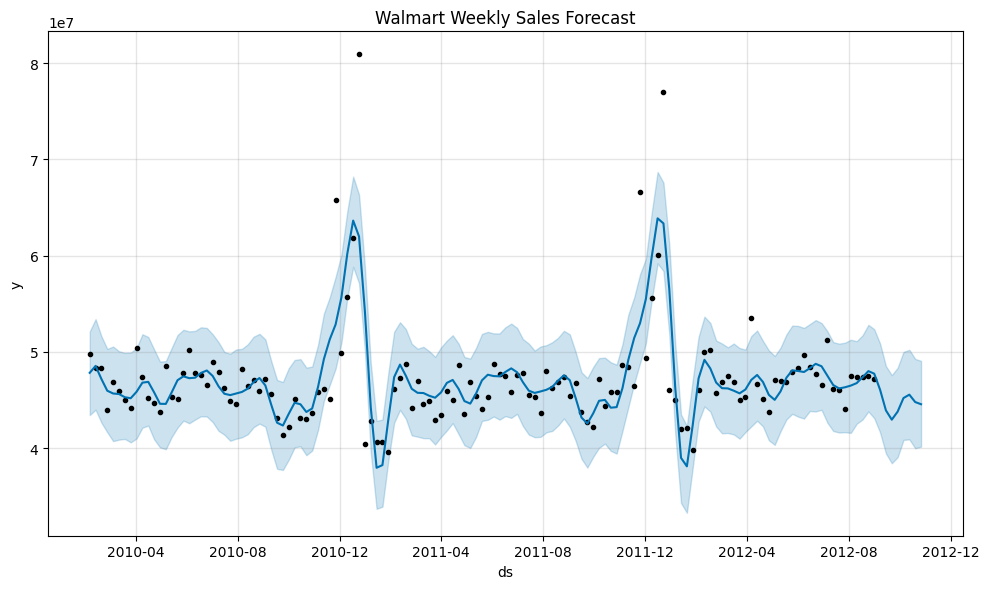

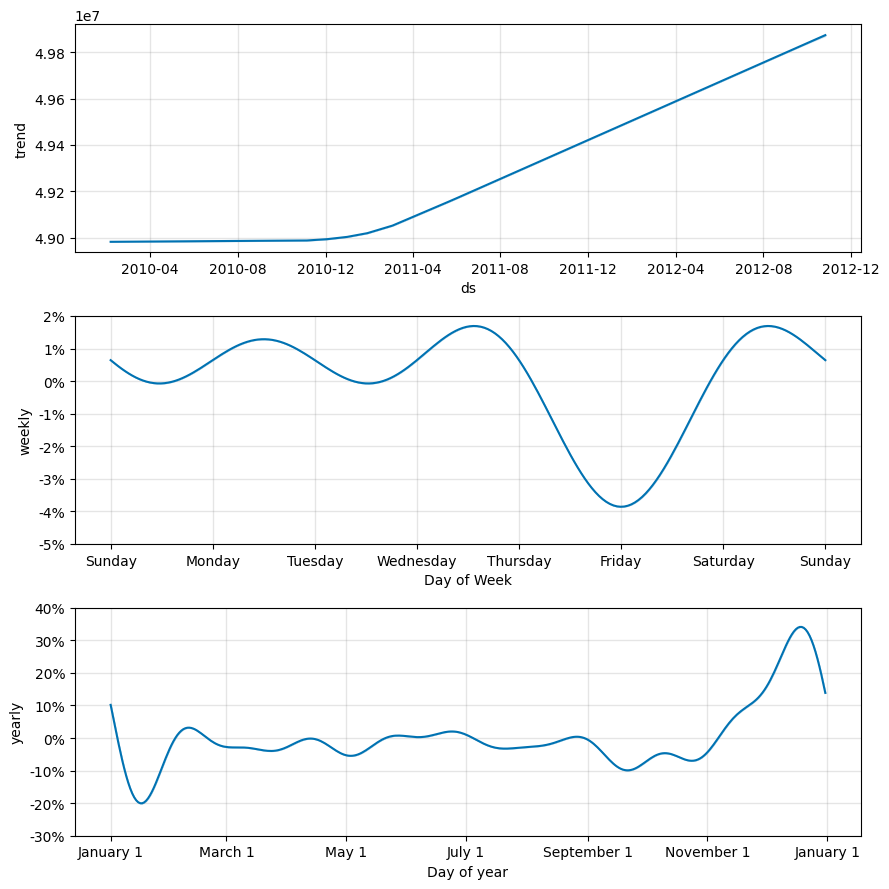

In [21]:
# Prophet built-in plot
fig1 = model.plot(forecast)
plt.title('Walmart Weekly Sales Forecast')
plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150)
plt.show()

# Components plot (trend + seasonality)
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150)
plt.show()

In [22]:
import joblib

joblib.dump(model, 'prophet_model.pkl')
print("Model saved!")

Model saved!


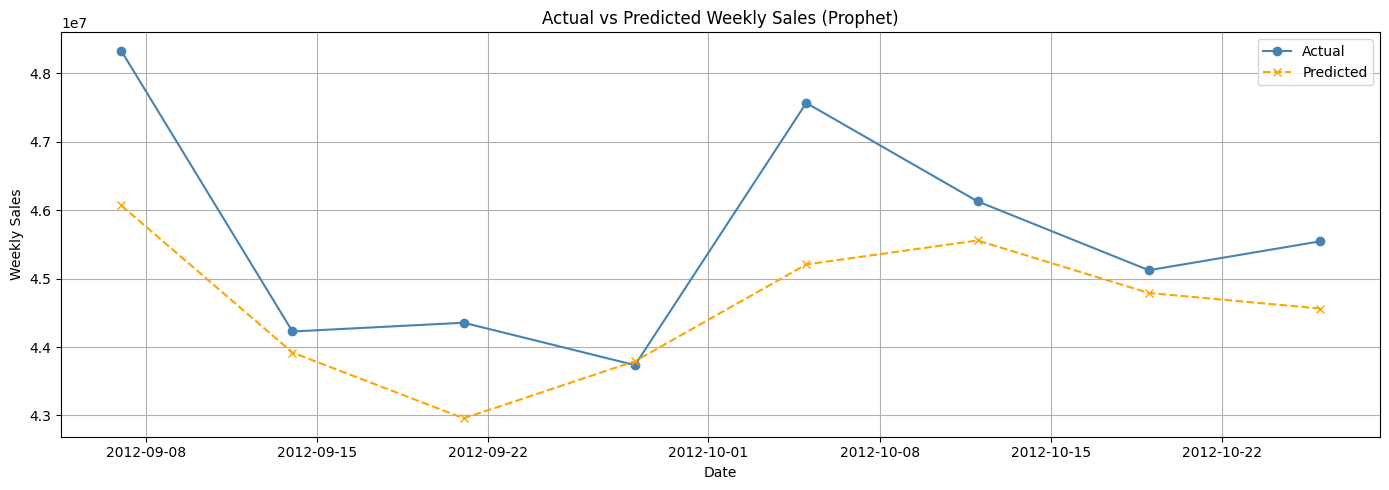

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(test_merged['ds'], test_merged['y'], label='Actual', color='steelblue', marker='o')
plt.plot(test_merged['ds'], test_merged['yhat'], label='Predicted', color='orange', linestyle='--', marker='x')
plt.title('Actual vs Predicted Weekly Sales (Prophet)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()